# Statistical analysis: Amazon Movies & TV reviews

This notebook analyzes **Movies_and_TV.csv** (McAuley Amazon review data: `item_id`, `user_id`, `rating`, `timestamp` — see [DatasetDescription.md](DatasetDescription.md)). Techniques follow [AnalyticalTechniques.md](AnalyticalTechniques.md): descriptive statistics, visualization, correlation, inference, probability, and classical bounds (LLN, Chebyshev).

**Note:** The CSV is very large (~8.7M rows). The loader draws a **random subsample** from fixed-size chunks so the notebook runs without loading the entire file into memory.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
import math

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load data (random sample from chunks)

Adjust `TARGET_SAMPLE_SIZE` to trade accuracy for speed.

In [2]:
CSV_PATH = "Movies_and_TV.csv"
COLS = ["item_id", "user_id", "rating", "timestamp"]
TARGET_SAMPLE_SIZE = 250_000
CHUNK_ROWS = 500_000

rng = np.random.default_rng(RANDOM_STATE)
parts = []
total_drawn = 0

for chunk in pd.read_csv(
    CSV_PATH,
    header=None,
    names=COLS,
    chunksize=CHUNK_ROWS,
):
    n = len(chunk)
    need = TARGET_SAMPLE_SIZE - total_drawn
    if need <= 0:
        break
    take = min(need, max(1, int(need * (n / CHUNK_ROWS))))
    take = min(take, n)
    idx = rng.choice(n, size=take, replace=False)
    parts.append(chunk.iloc[idx])
    total_drawn += take

df = pd.concat(parts, ignore_index=True)
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["hour"] = df["datetime"].dt.hour
df["liked"] = (df["rating"] >= 4).astype(int)

print(f"Sample rows: {len(df):,}")
df.head()

Sample rows: 250,000


,item_id,user_id,rating,timestamp,datetime,year,month,hour,liked
0,6302091632,A3HFY2A0MANEM2,5.0,1468972800,2016-07-20 00:00:00+00:00,2016,7,0,1
1,0792834976,AYIPYJ57SG75A,5.0,1501804800,2017-08-04 00:00:00+00:00,2017,8,0,1
2,0793906091,A38II8Q9I2JYDP,5.0,1455926400,2016-02-20 00:00:00+00:00,2016,2,0,1
3,0790734966,A3CN4Y8SCTA8B0,2.0,1453420800,2016-01-22 00:00:00+00:00,2016,1,0,0
4,6300181375,A1FUTZSXV3YPAG,1.0,1299283200,2011-03-05 00:00:00+00:00,2011,3,0,0


## 2. Descriptive statistics (central tendency & dispersion)

Mean, median, mode, range, sample variance / standard deviation, quartiles, IQR, and five-number summary for **rating**.

In [3]:
r = df["rating"]

desc = pd.Series(
    {
        "n": r.count(),
        "mean": r.mean(),
        "median": r.median(),
        "mode": r.mode().iloc[0] if len(r.mode()) else np.nan,
        "variance_sample": r.var(ddof=1),
        "std_sample": r.std(ddof=1),
        "min": r.min(),
        "max": r.max(),
        "range": r.max() - r.min(),
        "Q1": r.quantile(0.25),
        "Q2_median": r.quantile(0.50),
        "Q3": r.quantile(0.75),
        "IQR": r.quantile(0.75) - r.quantile(0.25),
    }
)
print("Rating — descriptive summary")
display(desc.to_frame("value"))

print(
    "Five-number summary (rating):",
    float(r.min()),
    float(desc["Q1"]),
    float(desc["Q2_median"]),
    float(desc["Q3"]),
    float(r.max()),
)

rating_counts = r.value_counts().sort_index()
print("\nRating frequencies (mode / multimodal check):")
display(rating_counts.to_frame("count"))

Rating — descriptive summary


,value
n,250000.000000
mean,4.389856
median,5.000000
mode,5.000000
variance_sample,1.216305
std_sample,1.102862
min,1.000000
max,5.000000
range,4.000000
Q1,4.000000


Five-number summary (rating): 1.0 4.0 5.0 5.0 5.0

Rating frequencies (mode / multimodal check):


,count
rating,
1.0,13399
2.0,8379
3.0,16773
4.0,40257
5.0,171192


## 3. Data visualization

Bar plot, histogram, KDE, box plot, scatter (time vs rating), and a correlation **heatmap**. The code cells that build each figure include **comments** describing what the chart encodes and how to read it (including caveats such as overplotting and discrete vs smoothed views).

/var/folders/qq/w0x7mqq17y3_vgq8xckwfb980000gp/T/ipykernel_64195/3005125818.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(r, vert=True, labels=["rating"])


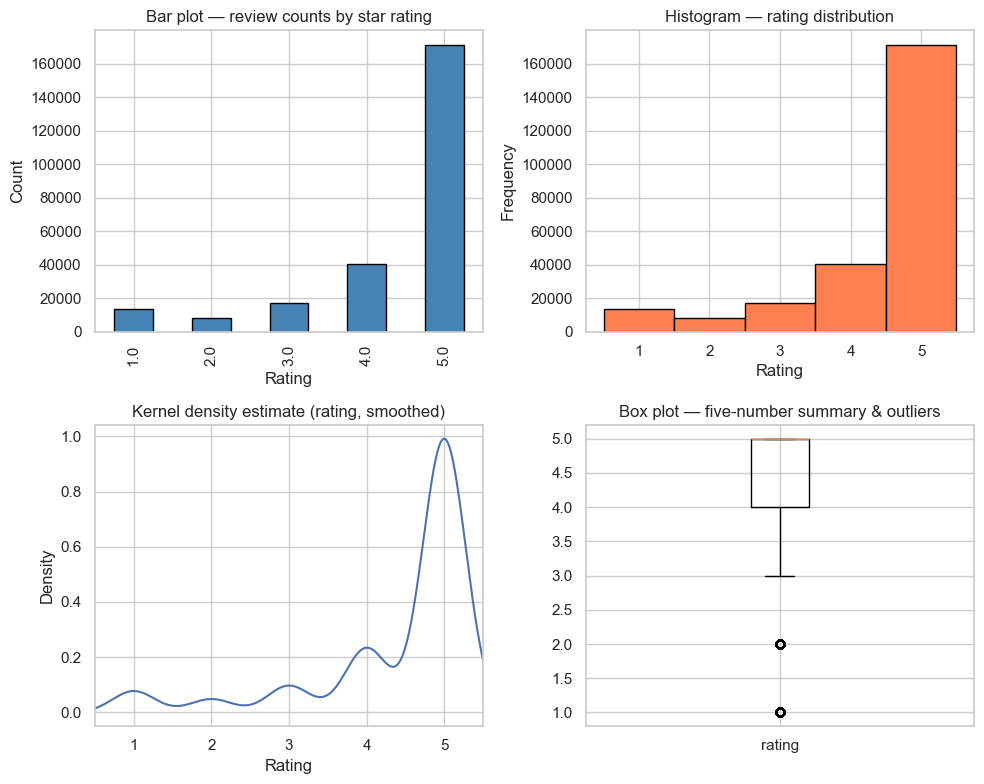

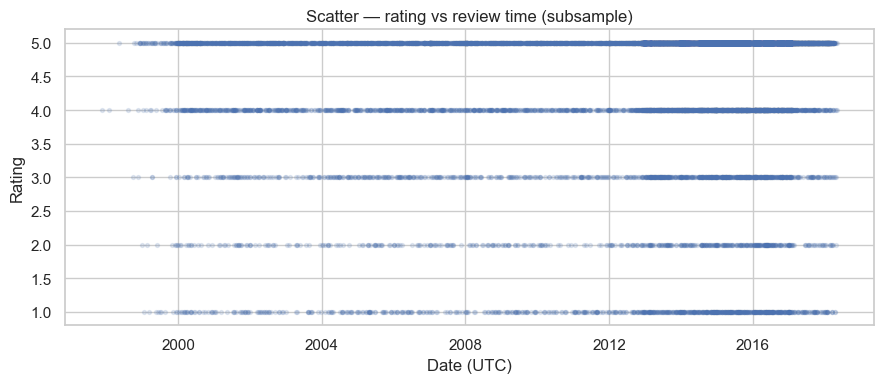

In [4]:
# === Figure 1: four-panel summary of star ratings (1–5) ===
# Bar chart (top-left): height = count of reviews with that star value in the sample.
#   Interpret: taller = more common; mass on 4–5 vs 1–2 shows positivity vs negativity skew.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax = axes[0, 0]
rating_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Bar plot — review counts by star rating")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")

# Histogram (top-right): same frequencies as the bar chart, bins centered at 1…5.
#   Interpret: shape (e.g. J-curve, single peak) matches the bar view; useful for “distribution shape” language.
ax = axes[0, 1]
r.plot.hist(bins=np.arange(0.5, 6.5, 1), ax=ax, color="coral", edgecolor="black")
ax.set_title("Histogram — rating distribution")
ax.set_xlabel("Rating")

# KDE (bottom-left): kernel density — smoothed curve over the rating scale.
#   Interpret: peaks ≈ where stars cluster; for discrete 1–5 data this is illustrative only, not a literal continuous density.
ax = axes[1, 0]
r.plot.density(ax=ax, bw_method=0.25)
ax.set_title("Kernel density estimate (rating, smoothed)")
ax.set_xlabel("Rating")
ax.set_xlim(0.5, 5.5)

# Box plot (bottom-right): median line; box spans Q1–Q3 (IQR); whiskers ~1.5×IQR; dots = outliers.
#   Interpret: where the central half of ratings lies; on a 1–5 scale outliers are rare but the box shows skew vs symmetry.
ax = axes[1, 1]
ax.boxplot(r, vert=True, labels=["rating"])
ax.set_title("Box plot — five-number summary & outliers")

plt.tight_layout()
plt.show()

# === Figure 2: scatter — each point is one review ===
# x-axis: datetime posted; y-axis: star rating (only values 1–5, so points lie on horizontal lines).
# Interpret: darker clouds (many semi-transparent points) = more reviews at that time/rating combo.
# Use for exploratory patterns (e.g. more activity in some years); do not over-interpret thin vertical trends
# without modeling—sampling and overlap make the eye unreliable for subtle effects.
scatter_n = min(15_000, len(df))
sub = df.sample(scatter_n, random_state=RANDOM_STATE)
plt.figure(figsize=(9, 4))
plt.scatter(sub["datetime"], sub["rating"], alpha=0.15, s=8)
plt.title("Scatter — rating vs review time (subsample)")
plt.xlabel("Date (UTC)")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

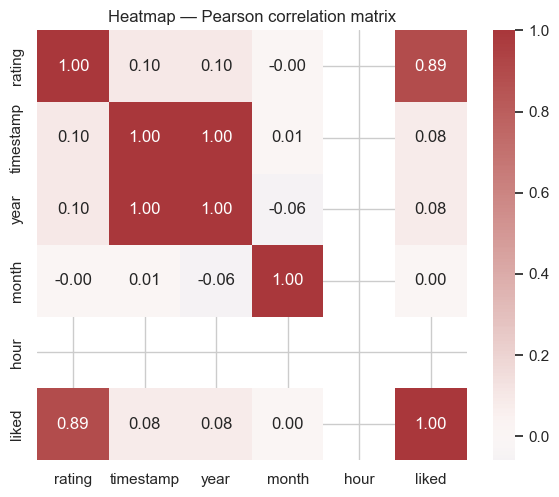

In [5]:
# --- Heatmap: Pearson correlation matrix for numeric features ---
# What it shows: Row/column labels are variables; each cell is r = linear correlation in [-1, 1].
# How to read it: Stronger red = stronger positive linear association; stronger blue = negative;
# near 0 (pale) = little linear relationship. Diagonal is always 1.0 (variable with itself).
# Caveats: Correlation is not causation. Pairs like rating vs liked look strong because "liked"
# is defined from rating. Timestamp vs year can be mechanically large; interpret those as structure
# of the data, not user behavior.
numeric_for_corr = df[["rating", "timestamp", "year", "month", "hour", "liked"]]
cm = numeric_for_corr.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Heatmap — Pearson correlation matrix")
plt.tight_layout()
plt.show()

## 4. Covariance & correlation

Sample covariance matrix, Pearson correlation, and a bivariate association (hour vs rating) with Pearson and Spearman. The **heatmap** cell includes comments on reading correlation strength, sign, and common caveats (e.g. definitional relationships).

In [6]:
cov = numeric_for_corr.cov()
print("Sample covariance matrix:")
display(cov)
print("\nPearson correlation matrix:")
display(cm)

x, y = df["hour"], df["rating"]
pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)
print(f"\nHour vs rating — Pearson r={pearson_r:.4f}, p={pearson_p:.2e}")
print(f"Hour vs rating — Spearman rho={spearman_r:.4f}, p={spearman_p:.2e}")

Sample covariance matrix:


,rating,timestamp,year,month,hour,liked
rating,1.216305e+00,1.556549e+07,4.933927e-01,-5.566831e-04,0.0,3.550308e-01
timestamp,1.556549e+07,2.113307e+16,6.693063e+08,4.006569e+06,0.0,4.253937e+06
year,4.933927e-01,6.693063e+08,2.128991e+01,-9.709612e-01,0.0,1.347950e-01
month,-5.566831e-04,4.006569e+06,-9.709612e-01,1.314494e+01,0.0,5.579557e-04
hour,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00
liked,3.550308e-01,4.253937e+06,1.347950e-01,5.579557e-04,0.0,1.304256e-01



Pearson correlation matrix:


,rating,timestamp,year,month,hour,liked
rating,1.000000,0.097087,0.096958,-0.000139,NaN,0.891381
timestamp,0.097087,1.000000,0.997830,0.007602,NaN,0.081027
year,0.096958,0.997830,1.000000,-0.058041,NaN,0.080892
month,-0.000139,0.007602,-0.058041,1.000000,NaN,0.000426
hour,NaN,NaN,NaN,NaN,NaN,NaN
liked,0.891381,0.081027,0.080892,0.000426,NaN,1.000000



Hour vs rating — Pearson r=nan, p=nan
Hour vs rating — Spearman rho=nan, p=nan


/var/folders/qq/w0x7mqq17y3_vgq8xckwfb980000gp/T/ipykernel_64195/1818349738.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r, pearson_p = stats.pearsonr(x, y)
/var/folders/qq/w0x7mqq17y3_vgq8xckwfb980000gp/T/ipykernel_64195/1818349738.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_r, spearman_p = stats.spearmanr(x, y)


## 5. Inferential statistics, A/B-style comparison, confidence intervals

- **One-sample t-test:** mean rating vs a reference value.  
- **Two-sample (Welch) t-test:** mean rating in earliest vs latest year with enough rows — analogous to comparing two “variants” (A/B).  
- **Paired t-test:** not applicable here (no natural paired measurements per user–item over time in this extract).  
- **One-sample binomial test:** proportion of reviews with rating ≥ 4 vs 0.5.  
- **95% confidence interval** for the mean rating.

In [7]:
t_stat, t_p = stats.ttest_1samp(r, popmean=3.0)
print(f"1-sample t-test: mean rating vs 3.0 → t={t_stat:.4f}, p-value={t_p:.2e}")

year_counts = df["year"].value_counts().sort_index()
years_ok = year_counts[year_counts >= 500].index.tolist()
if len(years_ok) >= 2:
    y_a, y_b = years_ok[0], years_ok[-1]
    a = df.loc[df["year"] == y_a, "rating"]
    b = df.loc[df["year"] == y_b, "rating"]
    t2, p2 = stats.ttest_ind(a, b, equal_var=False)
    print(
        f"2-sample Welch t-test (A/B-style years): {y_a} (n={len(a)}) vs {y_b} (n={len(b)}) → t={t2:.4f}, p={p2:.2e}"
    )
else:
    print("Skipping 2-sample t-test: not enough distinct years with sufficient counts in sample.")

k_success = int(df["liked"].sum())
n = len(df)
high_prop = k_success / n
bt = stats.binomtest(k_success, n=n, p=0.5, alternative="two-sided")
print(f"\nProportion rating ≥4: {high_prop:.4f}")
print(f"Binomial test vs p0=0.5 → p-value={bt.pvalue:.2e}")

ci_low, ci_high = stats.t.interval(
    confidence=0.95,
    df=len(r) - 1,
    loc=r.mean(),
    scale=stats.sem(r),
)
print(f"\n95% CI for mean rating: ({ci_low:.4f}, {ci_high:.4f})")

1-sample t-test: mean rating vs 3.0 → t=630.1131, p-value=0.00e+00
2-sample Welch t-test (A/B-style years): 1999 (n=1824) vs 2018 (n=3324) → t=-5.2877, p=1.31e-07

Proportion rating ≥4: 0.8458
Binomial test vs p0=0.5 → p-value=0.00e+00

95% CI for mean rating: (4.3855, 4.3942)


## 6. Probability: empirical PMF, Bernoulli, Poisson, combinatorics, conditional probability & Bayes

- Ratings {1,…,5} → **empirical PMF** (multinomial if viewed as categorical draws).  
- **Bernoulli:** “liked” (≥4) vs not.  
- **Poisson:** approximate model for **daily review counts** in this sample (illustrative fit). The **daily-count histogram** below has inline comments on interpretation and Poisson variance checks.  
- **Combinatorics:** small illustration (choices of star values).  
- **Conditional probability & Bayes:** relationship between a coarse time bucket and high ratings.

Empirical PMF P(rating = k):


,probability
rating,
1.0,0.053596
2.0,0.033516
3.0,0.067092
4.0,0.161028
5.0,0.684768


Bernoulli parameter (P(liked), rating≥4): 0.8458

Daily review counts — mean (Poisson MLE λ): 34.91, variance: 2278.04


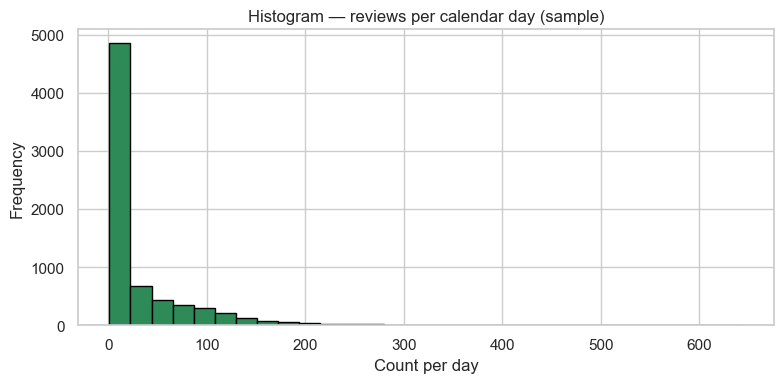

Combinatorics example: ordered 3-tuples from {1..5} with replacement: 125
  permutations of 3 distinct stars from 5: 60

P(rating≥4): 0.8458
P(rating≥4 | before median time): 0.8244
P(before median time | rating≥4): 0.4868
Bayes check P(early|high) ≈ P(high|early)*P(early)/P(high): 0.4868


In [8]:
pmf = rating_counts / rating_counts.sum()
print("Empirical PMF P(rating = k):")
display(pmf.to_frame("probability"))

p_like = df["liked"].mean()
print(f"Bernoulli parameter (P(liked), rating≥4): {p_like:.4f}")

daily = df.groupby(df["datetime"].dt.date).size()
lam_mle = daily.mean()
print(f"\nDaily review counts — mean (Poisson MLE λ): {lam_mle:.2f}, variance: {daily.var(ddof=1):.2f}")
# --- Histogram: how many reviews fall on each calendar day (aggregated into count bins) ---
# What it shows: Distribution of "reviews per day" across days present in this sample.
# How to read it: A long right tail means a few days have unusually many reviews; a peak near low
# counts means most days are quiet. For a Poisson model, compare mean and variance printed above
# (Poisson implies variance ≈ mean; variance much larger suggests overdispersion / burstiness).
plt.figure(figsize=(8, 4))
daily.plot.hist(bins=30, color="seagreen", edgecolor="black")
plt.title("Histogram — reviews per calendar day (sample)")
plt.xlabel("Count per day")
plt.tight_layout()
plt.show()

k_stars, n_draw = 3, 5
with_rep = n_draw ** k_stars
without_rep = math.perm(n_draw, k_stars) if n_draw >= k_stars else 0
print(f"Combinatorics example: ordered 3-tuples from {{1..5}} with replacement: {with_rep}")
print(f"  permutations of 3 distinct stars from 5: {without_rep}")

median_ts = df["timestamp"].median()
early = df["timestamp"] < median_ts
A = df["liked"] == 1
p_high = A.mean()
p_high_given_early = A[early].mean()
p_early = early.mean()
p_early_given_high = (early & A).sum() / A.sum()
bayes_check = (p_high_given_early * p_early) / p_high if p_high else np.nan
print(f"\nP(rating≥4): {p_high:.4f}")
print(f"P(rating≥4 | before median time): {p_high_given_early:.4f}")
print(f"P(before median time | rating≥4): {p_early_given_high:.4f}")
print(f"Bayes check P(early|high) ≈ P(high|early)*P(early)/P(high): {bayes_check:.4f}")

## 7. Law of large numbers (simulation)

Cumulative sample mean of **liked** (Bernoulli) as more reviews are included — stabilizes toward **p**. See comments on the plot cell for how to read the path vs the horizontal reference line.

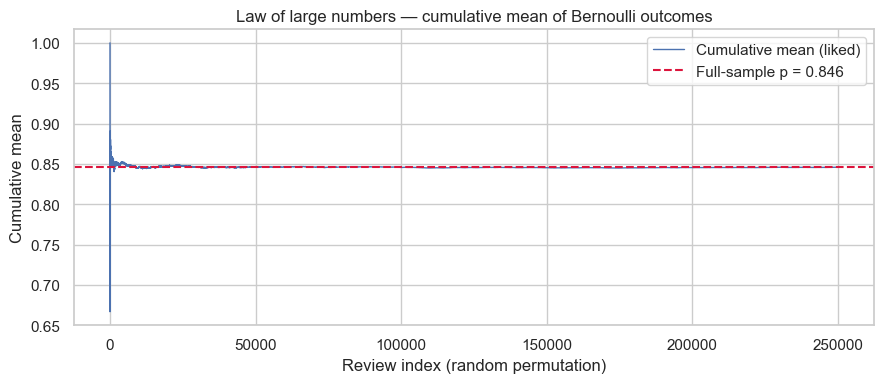

In [9]:
# --- Line plot: Law of large numbers (sample mean of Bernoulli "liked" converging) ---
# What it shows: After shuffling reviews, the running average of liked (1) vs not (0) as each
# review is added, versus the final overall proportion p_like (red dashed line).
# How to read it: Early on the path is volatile; with more data it should hug the dashed line.
# That illustrates LLN: sample means fluctuate less and center on the true success probability
# as sample size grows (here "true" means the proportion in this large sample / population proxy).
order = df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
x = order["liked"].to_numpy()
cum_mean = np.cumsum(x) / np.arange(1, len(x) + 1)
plt.figure(figsize=(9, 4))
plt.plot(cum_mean, lw=1, label="Cumulative mean (liked)")
plt.axhline(p_like, color="crimson", ls="--", label=f"Full-sample p = {p_like:.3f}")
plt.xlabel("Review index (random permutation)")
plt.ylabel("Cumulative mean")
plt.title("Law of large numbers — cumulative mean of Bernoulli outcomes")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Chebyshev’s inequality (rating)

For any distribution, **P(|X − μ| ≥ kσ) ≤ 1/k²**. Compare the **theoretical bound** to the **empirical** fraction in the sample for several **k**.

In [10]:
mu, sigma = float(r.mean()), float(r.std(ddof=1))
rows = []
for k in [1.0, 1.5, 2.0, 2.5, 3.0]:
    bound = 1 / (k ** 2)
    empirical = np.mean(np.abs(r - mu) >= k * sigma)
    rows.append({"k": k, "chebyshev_max_P": bound, "empirical_P": empirical})
cheb_df = pd.DataFrame(rows)
display(cheb_df)
print("Empirical proportion should be ≤ Chebyshev bound (often much smaller for bounded data).")

,k,chebyshev_max_P,empirical_P
0,1.0,1.000000,0.154204
1,1.5,0.444444,0.087112
2,2.0,0.250000,0.087112
3,2.5,0.160000,0.053596
4,3.0,0.111111,0.053596


Empirical proportion should be ≤ Chebyshev bound (often much smaller for bounded data).


## 9. Group comparison chart (pyramid-style substitute)

The course mentions **age pyramids** for two groups. This dataset has no age; we compare **rating distribution** between reviews **before** vs **after** the median timestamp. The plotting cell includes comments on what each pair of bars means and how to relate the view to formal tests.

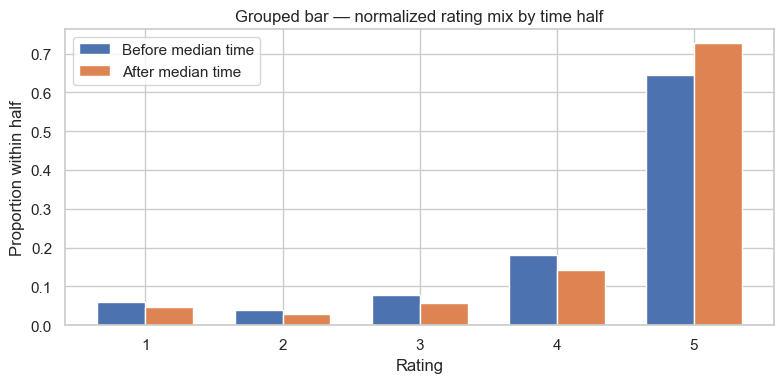

In [11]:
# --- Grouped bar chart: share of each star rating in early vs late half of the timeline ---
# What it shows: For reviews before vs after the median timestamp, each pair of bars is the
# proportion of that half's reviews that gave 1★, 2★, … (columns sum to 100% within each half).
# How to read it: If "after" has taller bars on 4–5 than "before," the later period looks more
# positive in this sample; the opposite suggests more low stars later. Small differences may be
# noise—use the formal two-sample tests elsewhere before claiming a real shift.
half = df["timestamp"] < df["timestamp"].median()
g_early = df.loc[half, "rating"].value_counts().sort_index()
g_late = df.loc[~half, "rating"].value_counts().sort_index()
plot_df = pd.DataFrame({"before_median": g_early, "after_median": g_late}).fillna(0)
plot_df = plot_df / plot_df.sum(axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(plot_df))
w = 0.35
ax.bar(x - w / 2, plot_df["before_median"], w, label="Before median time")
ax.bar(x + w / 2, plot_df["after_median"], w, label="After median time")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index.astype(int))
ax.set_xlabel("Rating")
ax.set_ylabel("Proportion within half")
ax.set_title("Grouped bar — normalized rating mix by time half")
ax.legend()
plt.tight_layout()
plt.show()